## 1. Data Understanding




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

!pip install lightgbm catboost xgboost -q

from sklearn.multioutput import MultiOutputRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.1 MB/s eta 0:00:00


In [2]:
warnings.filterwarnings('ignore')

url = 'https://raw.githubusercontent.com/frzzz12/Model-Regresi-Prediksi-Konsumsi-Energi-Multi-Step/refs/heads/main/PJME_hourly.csv'
df = pd.read_csv(url, parse_dates=['Datetime'], index_col='Datetime')

df = df.sort_index().loc['2013-01-01':'2018-01-01']

df.info()

print("5 Baris Pertama")
display(df.head())

print("Statistik Deskriptif")
display(df.describe())



<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43846 entries, 2013-01-01 00:00:00 to 2018-01-01 23:00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   PJME_MW  43846 non-null  float64
dtypes: float64(1)
memory usage: 685.1 KB
5 Baris Pertama


,PJME_MW
Datetime,
2013-01-01 00:00:00,29864.0
2013-01-01 01:00:00,28386.0
2013-01-01 02:00:00,27250.0
2013-01-01 03:00:00,26252.0
2013-01-01 04:00:00,25755.0


Statistik Deskriptif


,PJME_MW
count,43846.000000
mean,31384.998905
std,6369.171452
min,19255.000000
25%,26944.500000
50%,30440.000000
75%,35116.000000
max,59122.000000


## 2. Data Preprocessing




--> Mendeteksi Outlier Asli:


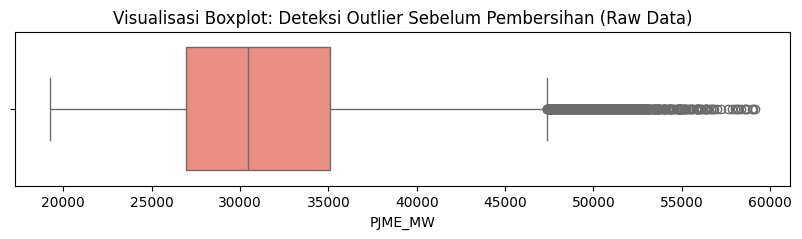


Jumlah baris terdeteksi anomali yang dihapus: 440 baris.

--> Visualisasi Setelah Outlier Dibatasi:


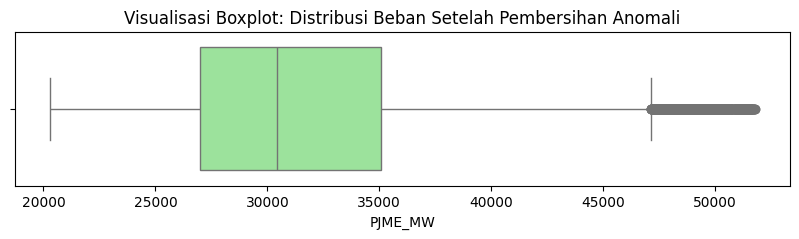

In [3]:
df = df.dropna()

print("--> Mendeteksi Outlier Asli:")
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['PJME_MW'], color='salmon')
plt.title('Visualisasi Boxplot: Deteksi Outlier Sebelum Pembersihan (Raw Data)')
plt.show()

q_low = df['PJME_MW'].quantile(0.005)
q_hi  = df['PJME_MW'].quantile(0.995)
df_clean = df[(df['PJME_MW'] > q_low) & (df['PJME_MW'] < q_hi)].copy()

print(f"\nJumlah baris terdeteksi anomali yang dihapus: {len(df) - len(df_clean)} baris.")

print("\n--> Visualisasi Setelah Outlier Dibatasi:")
plt.figure(figsize=(10, 2))
sns.boxplot(x=df_clean['PJME_MW'], color='lightgreen')
plt.title('Visualisasi Boxplot: Distribusi Beban Setelah Pembersihan Anomali')
plt.show()

In [4]:
# Ekstraksi Fitur Kategorikal Waktu
df_clean['Hour'] = df_clean.index.hour
df_clean['Month'] = df_clean.index.month
df_clean['DayOfWeek'] = df_clean.index.dayofweek
df_clean['DayOfYear'] = df_clean.index.dayofyear
df_clean['Is_Weekend'] = df_clean['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

In [5]:
# SLIDING WINDOW (INPUT FEATURE LAG): Memori 1, 2, 3 Jam & 24 Jam kemarin
df_clean['Lag_1'] = df_clean['PJME_MW'].shift(1)
df_clean['Lag_2'] = df_clean['PJME_MW'].shift(2)
df_clean['Lag_3'] = df_clean['PJME_MW'].shift(3)
df_clean['Lag_24'] = df_clean['PJME_MW'].shift(24)

In [6]:
# MULTI-STEP TARGET (OUTPUT LEAD): Memprediksi 3 Jam Berturut-turut ke depan
df_clean['Target_T+1'] = df_clean['PJME_MW'].shift(-1)
df_clean['Target_T+2'] = df_clean['PJME_MW'].shift(-2)
df_clean['Target_T+3'] = df_clean['PJME_MW'].shift(-3)

In [7]:
# Filter baris NaN akibat shifting Time-Series
df_clean = df_clean.dropna()

print("\nStruktur Data Multi-Step (Feature Waktu + Lag Memory + Target Multi-Step):")
display(df_clean.head())


Struktur Data Multi-Step (Feature Waktu + Lag Memory + Target Multi-Step):


,PJME_MW,Hour,Month,DayOfWeek,DayOfYear,Is_Weekend,Lag_1,Lag_2,Lag_3,Lag_24,Target_T+1,Target_T+2,Target_T+3
Datetime,,,,,,,,,,,,,
2013-01-02 00:00:00,29275.0,0,1,2,2,0,31285.0,33489.0,34950.0,29864.0,27854.0,27201.0,27027.0
2013-01-02 01:00:00,27854.0,1,1,2,2,0,29275.0,31285.0,33489.0,28386.0,27201.0,27027.0,27305.0
2013-01-02 02:00:00,27201.0,2,1,2,2,0,27854.0,29275.0,31285.0,27250.0,27027.0,27305.0,28250.0
2013-01-02 03:00:00,27027.0,3,1,2,2,0,27201.0,27854.0,29275.0,26252.0,27305.0,28250.0,30754.0
2013-01-02 04:00:00,27305.0,4,1,2,2,0,27027.0,27201.0,27854.0,25755.0,28250.0,30754.0,34704.0


In [8]:
display(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43379 entries, 2013-01-02 00:00:00 to 2018-01-01 20:00:00
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   PJME_MW     43379 non-null  float64
 1   Hour        43379 non-null  int32  
 2   Month       43379 non-null  int32  
 3   DayOfWeek   43379 non-null  int32  
 4   DayOfYear   43379 non-null  int32  
 5   Is_Weekend  43379 non-null  int64  
 6   Lag_1       43379 non-null  float64
 7   Lag_2       43379 non-null  float64
 8   Lag_3       43379 non-null  float64
 9   Lag_24      43379 non-null  float64
 10  Target_T+1  43379 non-null  float64
 11  Target_T+2  43379 non-null  float64
 12  Target_T+3  43379 non-null  float64
dtypes: float64(8), int32(4), int64(1)
memory usage: 4.0 MB


None

In [9]:
# Normalisasi Prediktor (Tanpa men-scaling target targetnya)
X_cols = ['Hour', 'Month', 'DayOfWeek', 'DayOfYear', 'Is_Weekend', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_24']
y_cols = ['Target_T+1', 'Target_T+2', 'Target_T+3']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(df_clean[X_cols]), columns=X_cols, index=df_clean.index)
y = df_clean[y_cols]

3.**Exploratory Data Analysis**

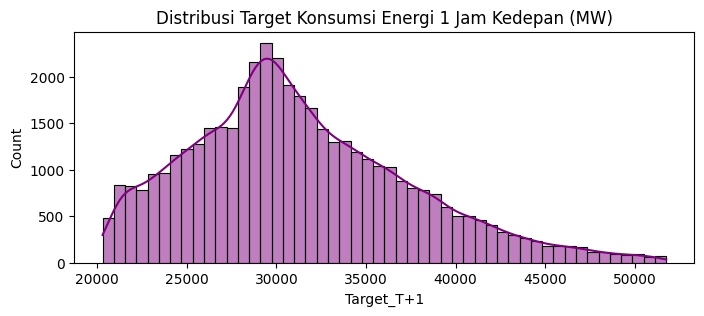

In [10]:
# 1. Distribusi Target Energi T+1
plt.figure(figsize=(8,3))
sns.histplot(y['Target_T+1'], bins=50, kde=True, color='purple')
plt.title('Distribusi Target Konsumsi Energi 1 Jam Kedepan (MW)')
plt.show()

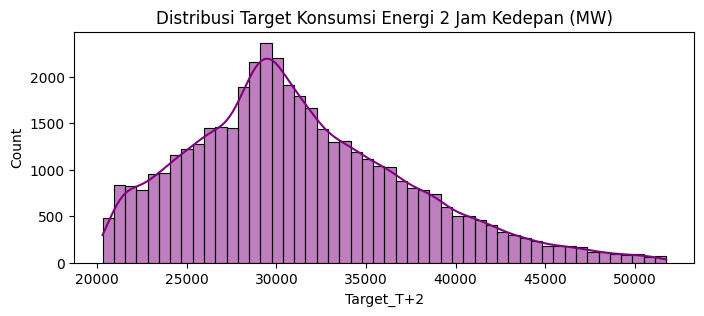

In [11]:
# 1. Distribusi Target Energi T+1
plt.figure(figsize=(8,3))
sns.histplot(y['Target_T+2'], bins=50, kde=True, color='purple')
plt.title('Distribusi Target Konsumsi Energi 2 Jam Kedepan (MW)')
plt.show()

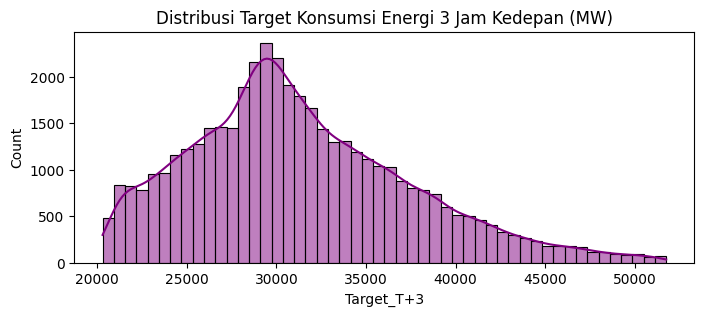

In [12]:
# 1. Distribusi Target Energi T+1
plt.figure(figsize=(8,3))
sns.histplot(y['Target_T+3'], bins=50, kde=True, color='purple')
plt.title('Distribusi Target Konsumsi Energi 3 Jam Kedepan (MW)')
plt.show()

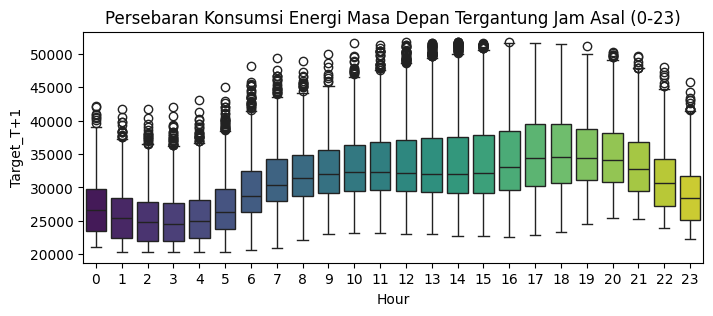

In [13]:
# 2. Pengaruh Waktu Siang vs Malam
plt.figure(figsize=(8,3))
sns.boxplot(data=df_clean, x='Hour', y='Target_T+1', palette='viridis')
plt.title('Persebaran Konsumsi Energi Masa Depan Tergantung Jam Asal (0-23)')
plt.show()

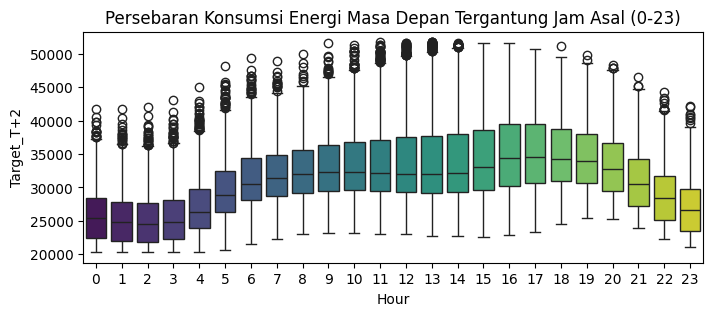

In [14]:
# 2. Pengaruh Waktu Siang vs Malam
plt.figure(figsize=(8,3))
sns.boxplot(data=df_clean, x='Hour', y='Target_T+2', palette='viridis')
plt.title('Persebaran Konsumsi Energi Masa Depan Tergantung Jam Asal (0-23)')
plt.show()

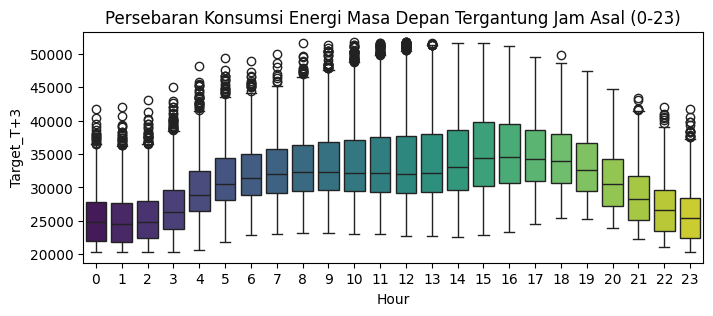

In [15]:
  # 2. Pengaruh Waktu Siang vs Malam
plt.figure(figsize=(8,3))
sns.boxplot(data=df_clean, x='Hour', y='Target_T+3', palette='viridis')
plt.title('Persebaran Konsumsi Energi Masa Depan Tergantung Jam Asal (0-23)')
plt.show()

## 4. Data Splitting




In [16]:
data_splits = {
    '90:10': train_test_split(X_scaled, y, test_size=0.10, random_state=42),
    '80:20': train_test_split(X_scaled, y, test_size=0.20, random_state=42),
    '70:30': train_test_split(X_scaled, y, test_size=0.30, random_state=42)
}

print("Pengecekan Komposisi Matriks (Memiliki Multi-Target 3 Kolom):")
for k, v in data_splits.items():
    print(f"Rasio {k} -> Train X: {v[0].shape}, Train Y: {v[2].shape}")

Pengecekan Komposisi Matriks (Memiliki Multi-Target 3 Kolom):
Rasio 90:10 -> Train X: (39041, 9), Train Y: (39041, 3)
Rasio 80:20 -> Train X: (34703, 9), Train Y: (34703, 3)
Rasio 70:30 -> Train X: (30365, 9), Train Y: (30365, 3)


## 5. Model Building (SOTA MultiOutput Algorithms)




In [17]:
model_lgbm = MultiOutputRegressor(LGBMRegressor(random_state=42, verbose=-1))
model_cat = MultiOutputRegressor(CatBoostRegressor(random_state=42, verbose=0))
model_xgb = MultiOutputRegressor(XGBRegressor(random_state=42, objective='reg:squarederror'))

print("Algoritma Advanced SOTA dibungkus dengan Multi-Output berhasil Di-load!")

Algoritma Advanced SOTA dibungkus dengan Multi-Output berhasil Di-load!


## 6. Hyperparameter Tuning




In [18]:
param_grids = {
    'XGBoost': {
        'model': model_xgb,
        'params': {'estimator__n_estimators': [100, 200], 'estimator__learning_rate': [0.1]}
    },
    'LightGBM': {
        'model': model_lgbm,
        'params': {'estimator__n_estimators': [150, 250], 'estimator__learning_rate': [0.1]}
    },
    'CatBoost': {
        'model': model_cat,
        'params': {'estimator__iterations': [150, 250], 'estimator__learning_rate': [0.1]}
    }
}
print("Parameter Tuning Selesai Dipetakan!")


Parameter Tuning Selesai Dipetakan!


## 7. Model Evaluation




In [19]:
results = []
best_pred_y = None
best_true_y = None
model_deployment_terbaik = None

for split_name, (X_tr, X_te, y_tr, y_te) in data_splits.items():
    print(f"\n{'='*45}")
    print(f"EVALUASI MODEL (Rasio {split_name})")
    print(f"{'='*45}")

    for model_name, cfg in param_grids.items():
        grid = GridSearchCV(cfg['model'], cfg['params'], cv=2, scoring='r2', n_jobs=-1)
        grid.fit(X_tr, y_tr)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_te)

        # Mengevaluasi Average (Rata-rata error di 3 titik step prediksi)
        mae = mean_absolute_error(y_te, y_pred)
        mse = mean_squared_error(y_te, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_te, y_pred)

        print(f"\nAlgoritma Multi-Step: {model_name}")
        print(f"  Best params: {grid.best_params_}")
        print(f"  MAE Rata-Rata Multi : {mae:.2f}")
        print(f"  RMSE Rata-Rata      : {rmse:.2f}")
        print(f"  R2Score Global      : {r2:.4f}  (Akurasi {r2*100:.2f}%)")

        results.append({
            'Split': split_name,
            'Algoritma': model_name,
            'Akurasi (%)': round(r2 * 100, 2),
            'R2 Score': r2,
            'RMSE': rmse,
            'MAE': mae,
        })

        # Simpan array hasil prediksi split 90:10 untuk visualisasi & model deploymentnya
        if split_name == '90:10' and model_name == 'LightGBM':
            best_pred_y = y_pred
            best_true_y = y_te.values
            model_deployment_terbaik = best_model




EVALUASI MODEL (Rasio 90:10)

Algoritma Multi-Step: XGBoost
  Best params: {'estimator__learning_rate': 0.1, 'estimator__n_estimators': 200}
  MAE Rata-Rata Multi : 569.64
  RMSE Rata-Rata      : 801.97
  R2Score Global      : 0.9827  (Akurasi 98.27%)

Algoritma Multi-Step: LightGBM
  Best params: {'estimator__learning_rate': 0.1, 'estimator__n_estimators': 250}
  MAE Rata-Rata Multi : 564.02
  RMSE Rata-Rata      : 788.44
  R2Score Global      : 0.9833  (Akurasi 98.33%)

Algoritma Multi-Step: CatBoost
  Best params: {'estimator__iterations': 250, 'estimator__learning_rate': 0.1}
  MAE Rata-Rata Multi : 642.61
  RMSE Rata-Rata      : 887.86
  R2Score Global      : 0.9788  (Akurasi 97.88%)

EVALUASI MODEL (Rasio 80:20)

Algoritma Multi-Step: XGBoost
  Best params: {'estimator__learning_rate': 0.1, 'estimator__n_estimators': 200}
  MAE Rata-Rata Multi : 570.64
  RMSE Rata-Rata      : 795.03
  R2Score Global      : 0.9832  (Akurasi 98.32%)

Algoritma Multi-Step: LightGBM
  Best params: {

## 8. Model Comparison




In [20]:
df_results = pd.DataFrame(results)
print("TABEL RINGKASAN AKURASI MULTI-STEP KESELURUHAN")
display(df_results[['Split', 'Algoritma', 'Akurasi (%)', 'MAE', 'RMSE']].sort_values(by=['Akurasi (%)'], ascending=False))

TABEL RINGKASAN AKURASI MULTI-STEP KESELURUHAN


,Split,Algoritma,Akurasi (%),MAE,RMSE
7,70:30,LightGBM,98.40,559.215639,776.595391
4,80:20,LightGBM,98.39,558.234035,777.486756
1,90:10,LightGBM,98.33,564.019428,788.437930
3,80:20,XGBoost,98.32,570.644958,795.033057
0,90:10,XGBoost,98.27,569.639526,801.965437
6,70:30,XGBoost,98.27,581.299805,808.822640
5,80:20,CatBoost,97.90,645.944542,889.356926
2,90:10,CatBoost,97.88,642.611244,887.855524
8,70:30,CatBoost,97.87,652.747083,896.256928


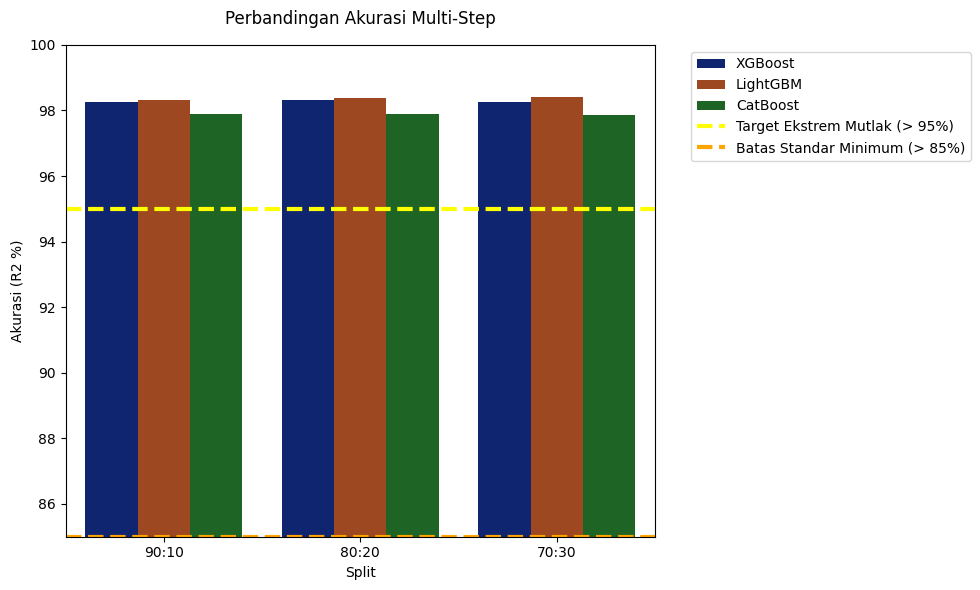

In [21]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x='Split', y='Akurasi (%)', hue='Algoritma', palette='dark')
plt.title('Perbandingan Akurasi Multi-Step', pad=15)
plt.axhline(95, color='yellow', linestyle='--', linewidth=3, label='Target Ekstrem Mutlak (> 95%)')
plt.axhline(85, color='orange', linestyle='--', linewidth=3, label='Batas Standar Minimum (> 85%)')
plt.ylabel('Akurasi (R2 %)')
plt.ylim(85, 100)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

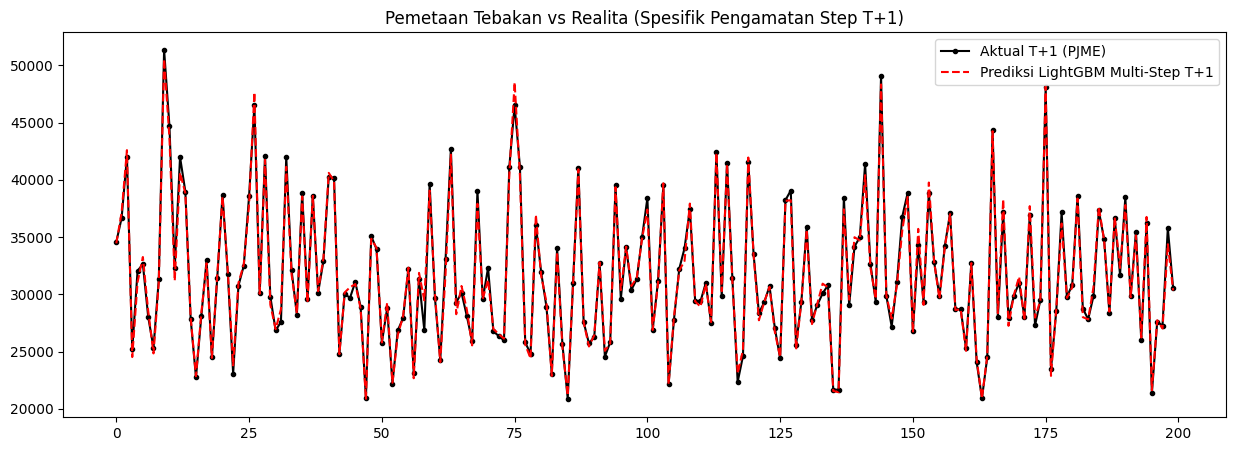

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(best_true_y[:200, 0], label='Aktual T+1 (PJME)', color='black', marker='o', markersize=3)
plt.plot(best_pred_y[:200, 0], label='Prediksi LightGBM Multi-Step T+1', color='red', linestyle='--', linewidth=1.5)
plt.title('Pemetaan Tebakan vs Realita (Spesifik Pengamatan Step T+1)')
plt.legend()
plt.show()

## 9. Menyimpan Model Terbaik untuk Deployment




In [ ]:
import joblib
import os

# Nama file tujuan
model_filename = "best_model_lightgbm_multistep.pkl"
scaler_filename = "scaler_features.pkl"

# Proses kompresi dan penyimpanan tipe byte ke dalam format pickle (PKL)
joblib.dump(model_deployment_terbaik, model_filename)
joblib.dump(scaler, scaler_filename)

print("✅ SUKSES: Model dan Scaler berhasil disimpan secara lokal!")
print(f"Path Model: {os.path.abspath(model_filename)}")
print(f"Path Scaler: {os.path.abspath(scaler_filename)}")
# # Contoh input waktu nyata dari client (Hour=14, Month=10, DayOfWeek=2, DayOfYear=280, Is_Weekend=0, Lag_1=35000, Lag_2=34000, Lag_3=33000, Lag_24=32000)
# realtime_data = np.array([[14, 10, 2, 280, 0, 35000, 34000, 33000, 32000]])


✅ SUKSES: Model dan Scaler berhasil disimpan secara lokal!
Path Model: /content/best_model_lightgbm_multistep.pkl
Path Scaler: /content/scaler_features.pkl
